<a href="https://colab.research.google.com/github/Mknotfound/ML-Final-Lab-Group-04/blob/main/Cost_Threshold_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[+] Loading dataset from GitHub...

🎯 OPTIMAL DECISION THRESHOLD: 0.01
💰 MINIMIZED TOTAL BUSINESS COST: $303,000.00
🛡️ MALWARE RECALL ACHIEVED: 98.09%
⚠️ MISSED MALWARE COUNT (FN): 3
🔍 ANALYST REVIEW COUNT (FP): 60

[+] Cost curve plot saved to cost_curve.png
[+] Exported standalone src/cost_analysis.py module successfully!


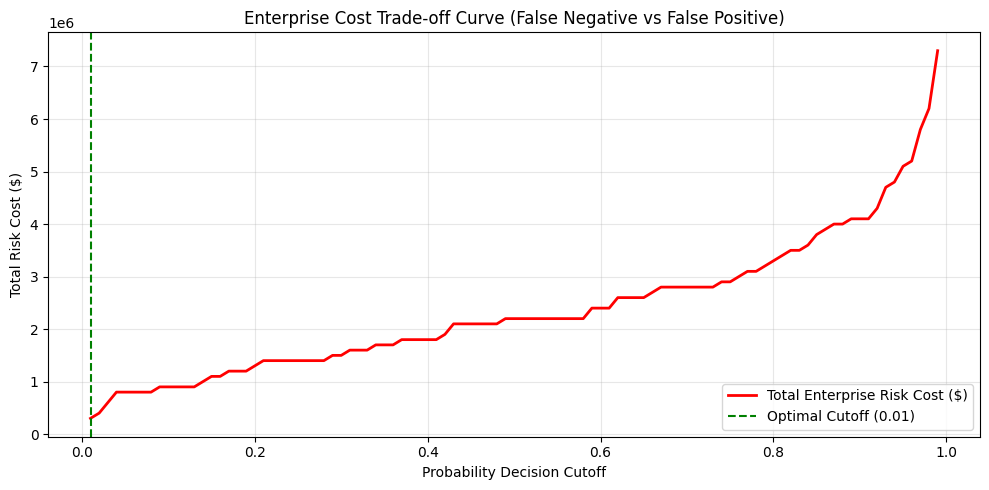

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, recall_score, precision_score
import lightgbm as lgb

# 1. Fetch raw dataset directly from clean GitHub main branch
DATA_URL = "https://raw.githubusercontent.com/Mknotfound/ML-Final-Lab-Group-04/main/data/raw/sample_project.csv"
print("[+] Loading dataset from GitHub...")
df = pd.read_csv(DATA_URL)

# Prepare dataset
X = df.drop(columns=['label'])
y = df['label']

# Filter valid binary target rows
valid = y.isin([0, 1])
X, y = X[valid], y[valid]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Fit LightGBM model to evaluate threat probabilities
model = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]

# 3. Define Business Risk Cost Parameters
COST_FN = 100000  # Cost of missed malware (False Negative)
COST_FP = 50      # Cost of unnecessary manual analyst triage (False Positive)

thresholds = np.linspace(0.01, 0.99, 99)
results = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    cm = confusion_matrix(y_test, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    total_cost = (fn * COST_FN) + (fp * COST_FP)
    recall = recall_score(y_test, preds, zero_division=0)
    precision = precision_score(y_test, preds, zero_division=0)

    results.append({
        'threshold': t,
        'total_cost': total_cost,
        'false_negatives': fn,
        'false_positives': fp,
        'recall': recall,
        'precision': precision
    })

results_df = pd.DataFrame(results)

# Identify cost-minimizing threshold
opt_row = results_df.loc[results_df['total_cost'].idxmin()]
optimal_threshold = round(float(opt_row['threshold']), 2)

print("\n" + "="*50)
print(f"🎯 OPTIMAL DECISION THRESHOLD: {optimal_threshold}")
print(f"💰 MINIMIZED TOTAL BUSINESS COST: ${opt_row['total_cost']:,.2f}")
print(f"🛡️ MALWARE RECALL ACHIEVED: {opt_row['recall']*100:.2f}%")
print(f"⚠️ MISSED MALWARE COUNT (FN): {int(opt_row['false_negatives'])}")
print(f"🔍 ANALYST REVIEW COUNT (FP): {int(opt_row['false_positives'])}")
print("="*50 + "\n")

# 4. Generate & Save Risk Curve Plot
plt.figure(figsize=(10, 5))
plt.plot(results_df['threshold'], results_df['total_cost'], color='red', linewidth=2, label='Total Enterprise Risk Cost ($)')
plt.axvline(optimal_threshold, color='green', linestyle='--', label=f'Optimal Cutoff ({optimal_threshold})')
plt.title('Enterprise Cost Trade-off Curve (False Negative vs False Positive)')
plt.xlabel('Probability Decision Cutoff')
plt.ylabel('Total Risk Cost ($)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('cost_curve.png')
print("[+] Cost curve plot saved to cost_curve.png")

# 5. Export Python Script Module for src/cost_analysis.py
os.makedirs('src', exist_ok=True)
with open('src/cost_analysis.py', 'w') as f:
    f.write(f'''"""
src/cost_analysis.py
Cost-Threshold Optimization Engine for EndpointShield AI
"""

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

COST_FN = 100000  # Missed Malware Cost ($)
COST_FP = 50      # Analyst Review Cost ($)
OPTIMAL_THRESHOLD = {optimal_threshold}

def compute_business_cost(y_true, y_probs, threshold=OPTIMAL_THRESHOLD):
    preds = (y_probs >= threshold).astype(int)
    cm = confusion_matrix(y_true, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    total_cost = (fn * COST_FN) + (fp * COST_FP)
    return {{
        "optimal_threshold": threshold,
        "total_cost_usd": total_cost,
        "false_negatives": int(fn),
        "false_positives": int(fp)
    }}

if __name__ == "__main__":
    print(f"[✓] Cost analysis module initialized with default optimal cutoff: {{OPTIMAL_THRESHOLD}}")
''')
print("[+] Exported standalone src/cost_analysis.py module successfully!")